### Python visualisation

This notebook uses the observations of one weather station in Belgium to illustrate the global evolution of mean monthly temperatures over several periods. It was created using Python 3.12.10

In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib as mlp
import matplotlib.pyplot as plt


### Load data Belgian temperature, one station, group per 28 consecutive years and calculate aggregated mean

In [3]:
df=pd.read_csv("data/ho_monthly_series_201_tn_v2024_01.csv", comment="#", index_col=0)
df=df.drop(index=2020)
print(df.tail())
jaartallen=list(df.index.get_level_values(level=0))
jaartallen_28=jaartallen[0::28]
new_jaartallen_index=[]
for j in jaartallen_28:
  new_jaartallen_index.append(f"{j}-{j+27}")


result = df.groupby(np.arange(len(df)) // 28).mean()
result.index = new_jaartallen_index
result.index.name = "YYYY"

result
print(result)

        1    2    3    4     5     6     7     8     9    10   11   12
YYYY                                                                  
2015  1.2 -0.2  2.1  4.1   8.6  11.5  14.4  14.1  10.0   6.2  6.7  7.3
2016  2.1  2.1  1.4  4.4   9.8  13.6  14.6  13.5  12.5   6.1  3.1  1.4
2017 -1.5  2.6  3.8  3.6  10.0  14.3  14.1  13.4   9.6  10.2  4.6  2.6
2018  3.3 -2.2  0.7  6.9  10.9  13.8  16.2  14.7  10.2   6.8  3.0  3.6
2019  1.4  1.1  4.7  4.9   7.8  13.1  14.4  14.0  10.5   9.0  2.5  2.5
                  1         2         3         4         5          6  \
YYYY                                                                     
1880-1907 -1.250000 -0.685714  0.771429  3.642857  7.328571  10.728571   
1908-1935  0.021429 -0.328571  1.153571  3.675000  7.864286  10.507143   
1936-1963 -1.032143 -0.921429  1.385714  4.382143  7.575000  10.775000   
1964-1991  0.064286 -0.310714  1.657143  3.775000  8.046429  11.178571   
1992-2019  0.985714  0.939286  2.528571  5.085714  9.317857

### Get some colors for later use

In [6]:
colors = plt.colormaps['Dark2'].colors
print(colors)

((0.10588235294117647, 0.6196078431372549, 0.4666666666666667), (0.8509803921568627, 0.37254901960784315, 0.00784313725490196), (0.4588235294117647, 0.4392156862745098, 0.7019607843137254), (0.9058823529411765, 0.1607843137254902, 0.5411764705882353), (0.4, 0.6509803921568628, 0.11764705882352941), (0.9019607843137255, 0.6705882352941176, 0.00784313725490196), (0.6509803921568628, 0.4627450980392157, 0.11372549019607843), (0.4, 0.4, 0.4))


### Visualise periodic mean monthly temperatures

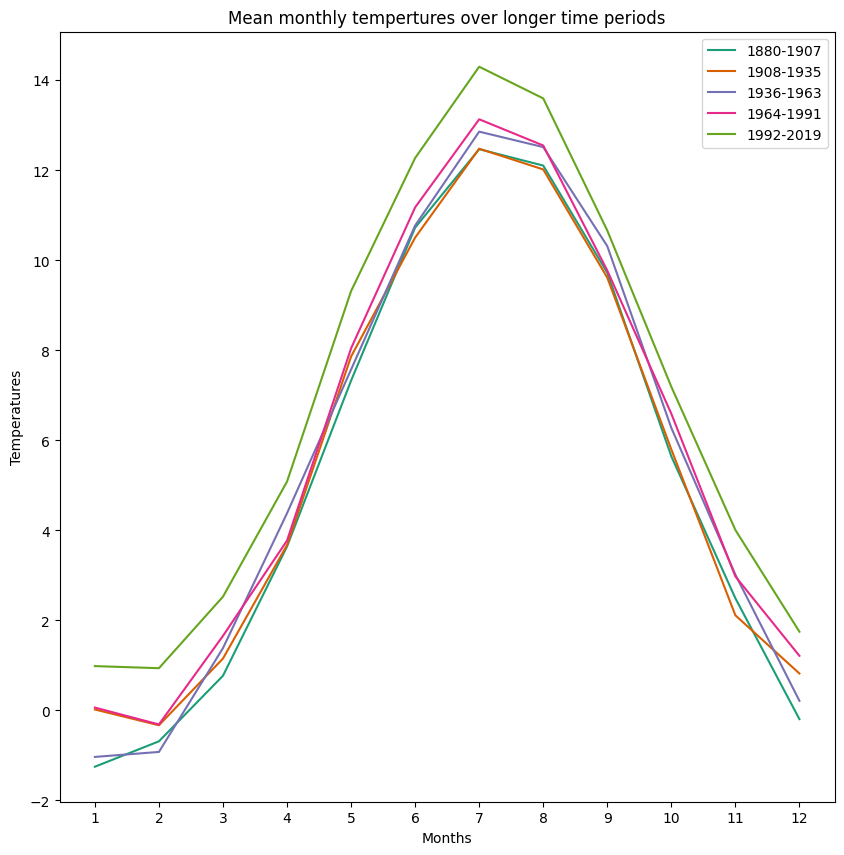

In [9]:
result_t=result.transpose()
fig,ax=plt.subplots(1,1,figsize=(10,10))
for i in range(5):
    ax.plot(result_t.iloc[:,i], label=result_t.columns[i], color=colors[i])

plt.xlabel("Months")
plt.ylabel("Temperatures")
plt.title("Mean monthly tempertures over longer time periods")
plt.legend()

### Visualize monthly temperatures between last and first period

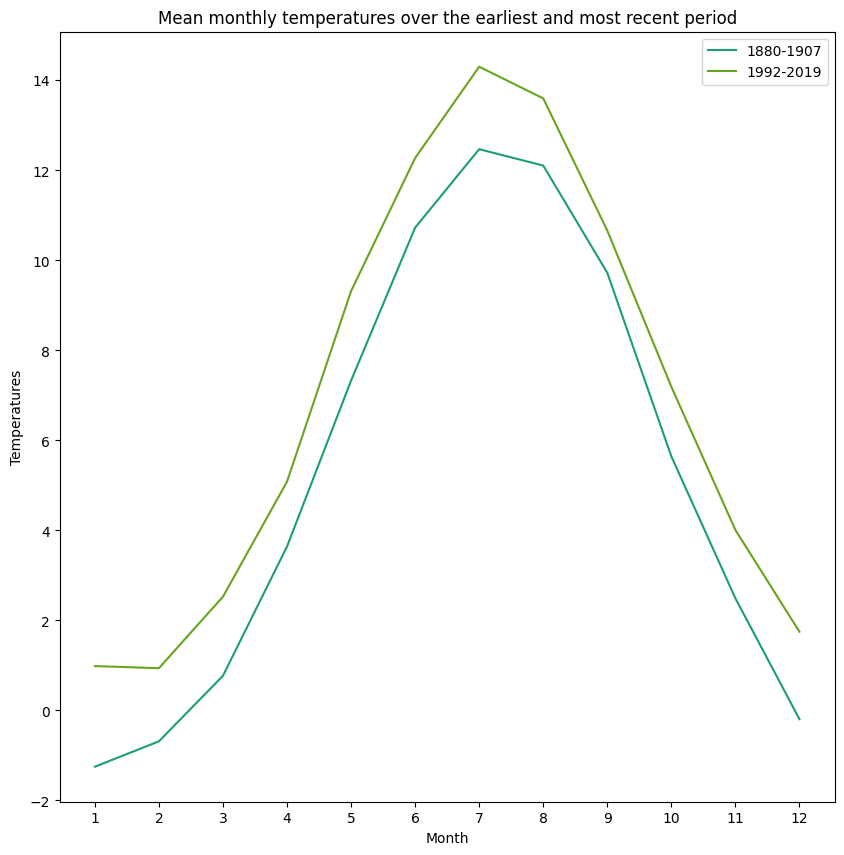

In [12]:
fig,ax=plt.subplots(1,1,figsize=(10,10))
selection=[0,4]
for i in selection:
    ax.plot(result_t.iloc[:,i], label=result_t.columns[i], color=colors[i])

plt.xlabel("Month")
plt.ylabel("Temperatures")
plt.title("Mean monthly temperatures over the earliest and most recent period")
plt.legend()

### Mean monthly temperatures over last two periods

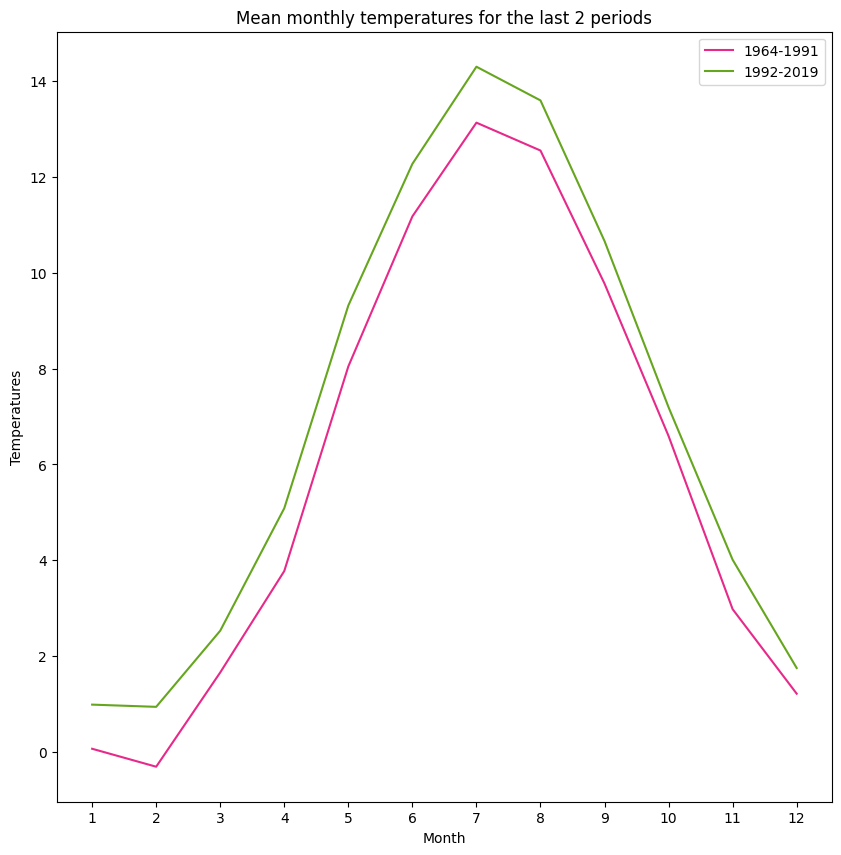

In [15]:
fig,ax=plt.subplots(1,1,figsize=(10,10))
selection=[3,4]
for i in selection:
    ax.plot(result_t.iloc[:,i], label=result_t.columns[i], color=colors[i])

plt.xlabel("Month")
plt.ylabel("Temperatures")
plt.title("Mean monthly temperatures for the last 2 periods")
plt.legend()

### Calculating monthly temperature mean differences for consecutive periods

In [16]:
differences = result_t.diff(axis=1, periods=1)
ncols=[]
col_names=list(differences.columns)
for i,c in enumerate(col_names):
  if i<len(col_names)-1:
    ncols.append("diff"+" "+col_names[i]+" "+col_names[i+1])

differences=differences.drop(columns=['1880-1907'])
differences.columns = ncols

tot_diff=result.loc["1992-2019"]-result.loc["1880-1907"]
differences["total_diff"]=tot_diff

### Visualize global monthly temperature period differences and cummulative overview

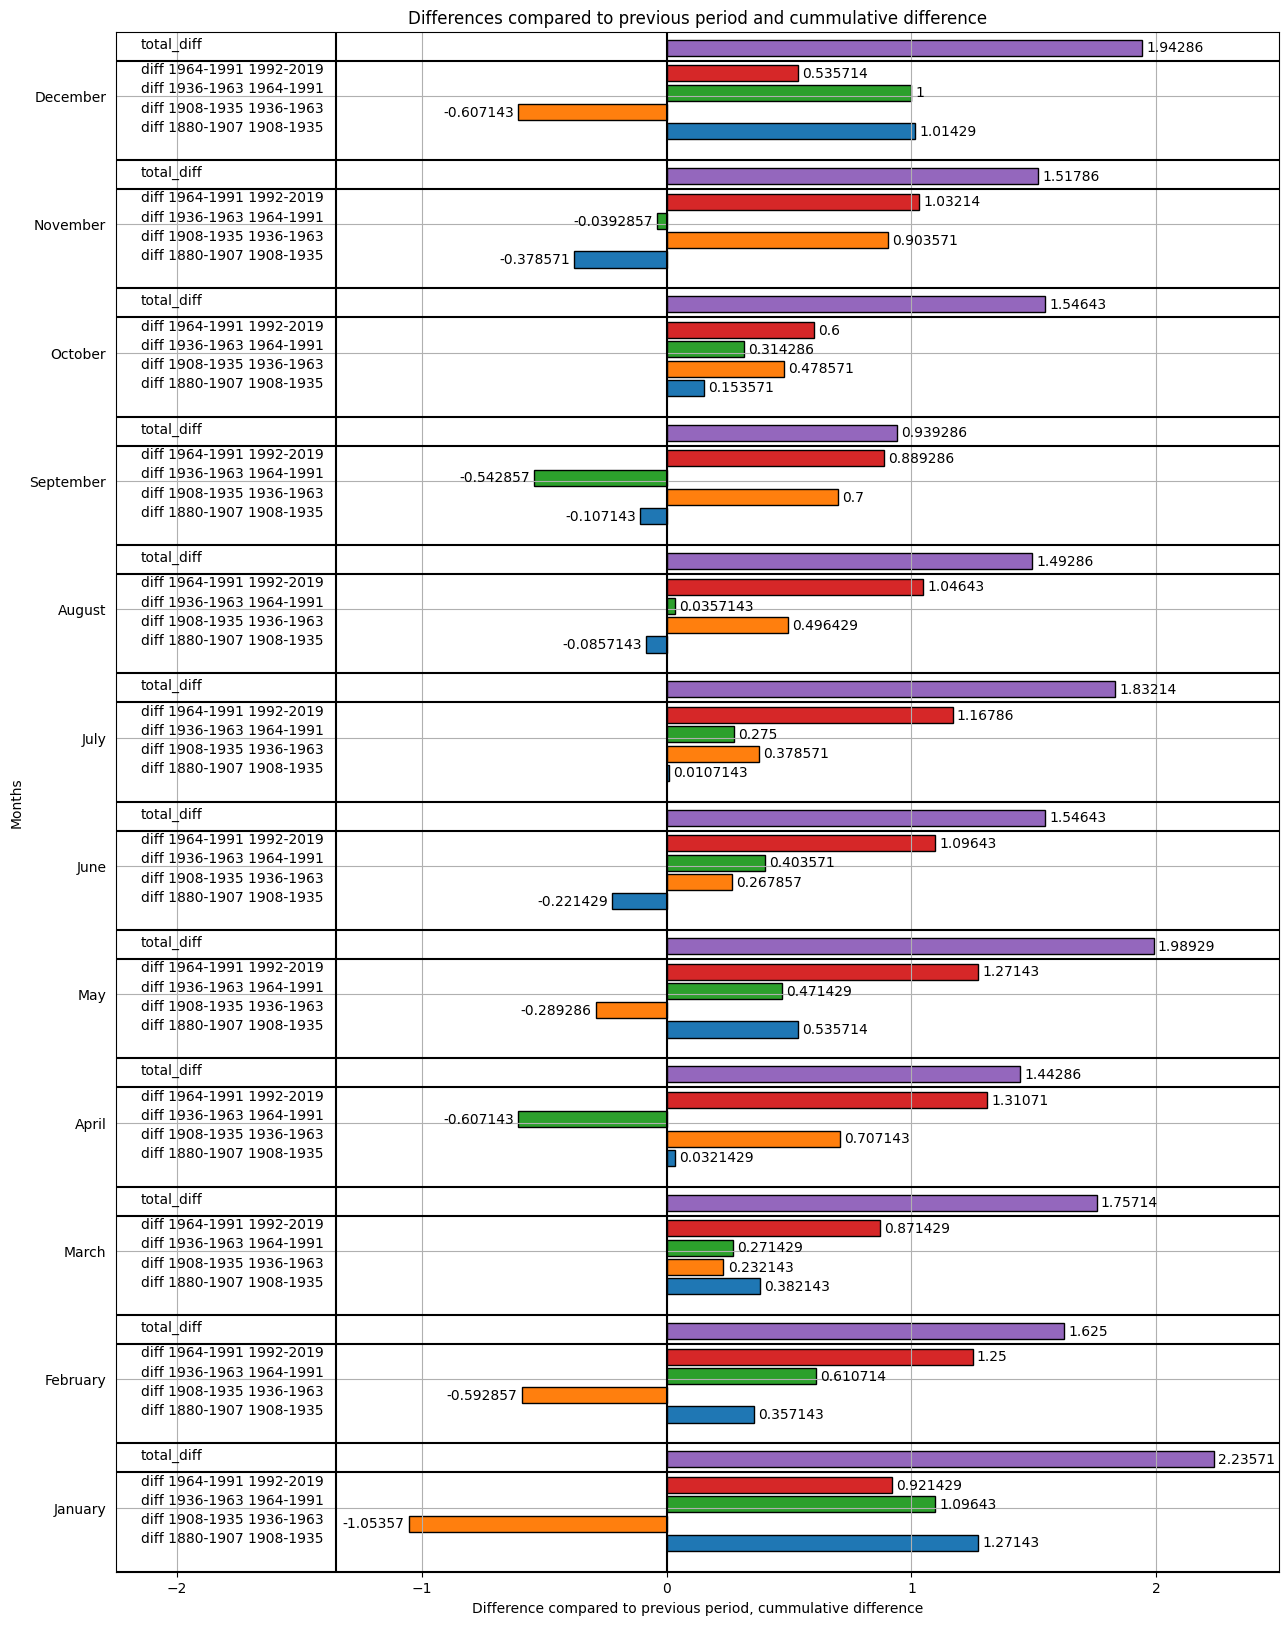

In [ ]:
import calendar

fig,ax=plt.subplots(figsize=(15,20))

list_of_months_names = list(calendar.month_name)[1:]
list_of_months_values= range(1,13)
m_dict={}
for mn, mv in zip(list_of_months_names, list_of_months_values):
    m_dict[str(mv)]=mn

differences.rename(index=m_dict, inplace=True)

dif_t=differences.transpose()

#y positions for bars
y_4=np.arange(1.375,13,1)
y_3=np.arange(1.175,13,1)
y_2=np.arange(1.025,13,1)
y_1=np.arange(0.875,12,1)
y_0=np.arange(0.725,12,1)

y_pos= pd.DataFrame([y_0,y_1,y_2,y_3,y_4])

for j in range(dif_t.shape[0]):
  bars= ax.barh(y_pos.iloc[j,:], dif_t.iloc[j,:],height=0.125,   edgecolor='black')
  ax.bar_label(bars, padding=3)

for j in range(dif_t.shape[0]):
  for i in range(dif_t.shape[1]):
    ax.annotate(list(dif_t.index)[j],xy=(-2.15, y_pos.iloc[j,i]))

y_lines= np.arange(0.5,12.5,1)
for v in y_lines:
  ax.axhline(v, color='black')

x_lines=[-1.35,0]
for v in x_lines:
  ax.axvline(v, color='black')

extra_ylines=np.arange(1.275,13,1)
for v in extra_ylines:
  ax.axhline(v, color='black')

ax.set_yticks(list_of_months_values)
ax.set_yticklabels(list_of_months_names)
plt.xlabel("Difference compared to previous period, cummulative difference")
plt.ylabel("Months")
plt.title("Differences compared to previous period and cummulative difference")
plt.ylim(0.5, 12.5)
plt.xlim(-2.25, 2.5)
plt.grid()
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    left=False,     # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) #

### Create dataframes for first and last period

In [4]:
print(df.shape)
first_period=df.iloc[:28,:]
print("first period")
print(first_period.head())
print(first_period.shape)

last_period=df.iloc[112:140,:]
print("last period")
print(last_period.head())
print(last_period.shape)

(140, 12)
first period
        1    2    3    4    5     6     7     8     9   10   11   12
YYYY                                                                
1880 -3.6  0.8  2.1  5.0  6.7  11.1  13.3  13.2  11.2  5.4  2.4  3.0
1881 -5.5 -0.1  1.9  3.1  7.8  10.1  13.6  12.1   9.9  3.6  5.8  0.6
1882  0.8  1.2  3.7  4.2  7.8  10.3  12.1  12.1   9.9  7.5  3.5  1.0
1883  1.1  2.2 -2.2  3.3  7.4  11.5  12.9  12.5   9.6  7.0  3.3  1.5
1884  3.4  2.2  2.2  2.6  7.8   9.0  14.0  13.1  11.2  5.6  0.9  1.4
(28, 12)
last period
        1    2    3    4     5     6     7     8     9   10   11   12
YYYY                                                                 
1992  0.6  1.5  3.7  4.9  10.9  13.0  14.0  14.3  10.2  4.3  5.0  1.5
1993  2.2 -0.1  0.2  5.9  10.0  12.1  13.2  11.4   9.6  6.1 -0.1  3.0
1994  2.5 -1.2  4.0  4.4   8.3  11.7  15.8  13.2  10.5  5.4  7.0  2.7
1995  1.3  3.9  1.3  5.0   8.1  11.0  15.4  14.6  10.7  7.8  2.3 -2.8
1996 -1.6 -1.7 -0.4  3.6   6.8  11.6  12.2  12.6   8.

In [6]:
import numpy as np
from scipy.stats import shapiro
from numpy.random import randn

### Create directories

In [7]:
import os

try:
    os.makedirs("temperature")
except:
    print('dir already exists')

try:
    os.makedirs("temperature/hists")
except:
    print('dir already exists')

try:
    os.makedirs("temperature/qplots")
except:
    print('dir already exists')

### Create histograms for every period and monthly temperature

To get an idea of the normality of the mean monthly temperatures, some bell curve is expected for all monthly observations.

In [5]:
def plot_hists(df):
  for col in first_period.columns:
    plt.hist(last_period[col], bins=5, edgecolor='black')
    plt.savefig("temperature/hists/"+col+ "_hist.png" )
    plt.close()

In [8]:
plot_hists(first_period)
plot_hists(last_period)

### Create qq plots

Data should produce a straight line to be reckoned normal. It is better than a histogram, as a histogram also depends on a bin size.

In [9]:
from scipy import stats


def qplot(df):
  for col in first_period.columns:
    fig, ax = plt.subplots(figsize=(6, 6))
    stats.probplot(df[col], plot=ax)
    plt.savefig("temperature/qplots/"+col+ "_qplot.png" )
    plt.close()

In [10]:
qplot(first_period)
qplot(last_period)

### Statistical test

A real statistical test automates the process. From this test we can conclude that not all monthly mean temperature observations are normally distributed

In [11]:
def my_shapiro(df):
    alpha = 0.05
    for col in df.columns:
      stat,p=stats.shapiro(df[col])
      print(f"stat {stat} p {p}")
      alpha = 0.05
      if p > alpha:
        print(f"The data for month {col} is likely normally distributed (Fail to Reject H0), because p-value>0.5.")
      else:
        print(f"The data for month {col} is likely not normally distributed (Reject H0).")

In [12]:
my_shapiro(first_period)

stat 0.9646134646394542 p 0.44567557792277607
The data for month 1 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.9193056534288153 p 0.03334327997562087
The data for month 2 is likely not normally distributed (Reject H0).
stat 0.9665556134428995 p 0.4918709365377055
The data for month 3 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.9601163349998039 p 0.35089470113619337
The data for month 4 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.9576466325753927 p 0.3062163525630355
The data for month 5 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.9351996922375391 p 0.08346201917886928
The data for month 6 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.9484033315838356 p 0.18061082108895038
The data for month 7 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.9553278282262514 p 0.26883293732482083
T

In [13]:
my_shapiro(last_period)

stat 0.9541110750015132 p 0.25089561835578245
The data for month 1 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.9790597969420285 p 0.8273135120937503
The data for month 2 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.949357878636119 p 0.19089744169358985
The data for month 3 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.9597657244092359 p 0.34423730715679324
The data for month 4 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.957746226290522 p 0.30791926000711445
The data for month 5 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.9248238853788162 p 0.04571116782375611
The data for month 6 is likely not normally distributed (Reject H0).
stat 0.9820932019276052 p 0.8972063107734699
The data for month 7 is likely normally distributed (Fail to Reject H0), because p-value>0.5.
stat 0.979048525375584 p 0.8270301749951704
The d

### Compare monthly variances

Equal variances adds more validity to a Mann Withney U test. A t-test can't be performed as not all monthly observations are normally distributed. The mann withney u test takes the ranking sum of both groups into consideration and establishes whether two groups differ when ranked as one group of observations.

In this case monthly observations seem to have same variances according to Levene test. The 0 hypothesis is that variances are the same. 

In [16]:
variances_df= pd.concat([first_period.var(), last_period.var()], axis=1)
variances_df.columns=["var first period", "var last period"]
print(variances_df)

    var first period  var last period
1           5.619630         5.709418
2           5.544974         4.093585
3           2.702116         2.419894
4           0.961799         1.346455
5           1.053228         1.420780
6           0.816931         0.798981
7           0.996190         1.356653
8           0.826614         0.894074
9           0.890093         1.360899
10          2.461098         2.853280
11          2.523651         2.538770
12          4.715503         4.741852


In [21]:
def compare_variances_for_dfs(first,second, variances_df):
  stat_list=[]
  p_list=[]
  for col in first.columns:
    stat, p_value = stats.levene(first[col],second[col])
    stat_list.append(stat)
    p_list.append(p_value)
  variances_df["p levene var"]=p_list
  return variances_df



In [23]:
results= compare_variances_for_dfs(first_period, last_period, variances_df)
print(results)

    var first period  var last period  p levene var
1           5.619630         5.709418      0.678980
2           5.544974         4.093585      0.779800
3           2.702116         2.419894      0.512087
4           0.961799         1.346455      0.671446
5           1.053228         1.420780      0.248975
6           0.816931         0.798981      0.950662
7           0.996190         1.356653      0.395514
8           0.826614         0.894074      0.451952
9           0.890093         1.360899      0.363403
10          2.461098         2.853280      0.905687
11          2.523651         2.538770      0.429138
12          4.715503         4.741852      0.959675


In [20]:
import scipy

def do_mann_withney_u(first,second):
  stat_list=[]
  p_list=[]
  for col in first.columns:
    stat, p_value =stats.mannwhitneyu(first[col], second[col], alternative='two-sided')
    stat_list.append(stat)
    p_list.append(p_value)
  return stat_list,p_list

In [25]:
st, p=do_mann_withney_u(first_period,last_period)


results["p man withney u"]=p
results["first period mean"]=first_period.mean()
results["last period mean"]=last_period.mean()
results["first period median"]=first_period.median()
results["last period median"]=last_period.median()
results["median diff"]=last_period.median()-first_period.median()
results["mean diff"]=last_period.mean()-first_period.mean()
print(results)

    var first period  var last period  p levene var  p man withney u  \
1           5.619630         5.709418      0.678980     1.015768e-03   
2           5.544974         4.093585      0.779800     1.595531e-02   
3           2.702116         2.419894      0.512087     2.407474e-04   
4           0.961799         1.346455      0.671446     1.390635e-05   
5           1.053228         1.420780      0.248975     6.090113e-07   
6           0.816931         0.798981      0.950662     7.031372e-07   
7           0.996190         1.356653      0.395514     9.437577e-07   
8           0.826614         0.894074      0.451952     8.654222e-07   
9           0.890093         1.360899      0.363403     2.912193e-03   
10          2.461098         2.853280      0.905687     1.939886e-03   
11          2.523651         2.538770      0.429138     7.539621e-04   
12          4.715503         4.741852      0.959675     6.478776e-04   

    first period mean  last period mean  first period median  \

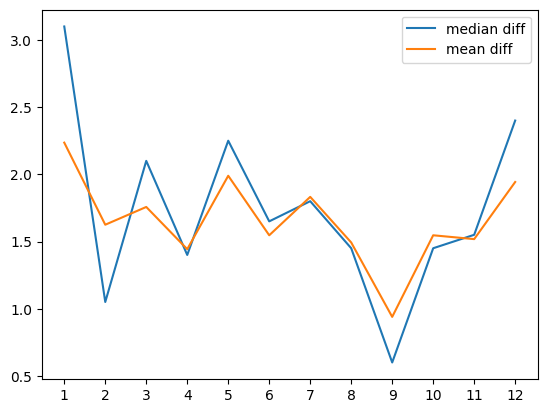

In [ ]:
focus = results[["median diff", "mean diff"]]
for col in focus.columns:
  plt.plot(focus[col], label=col)


plt.legend()

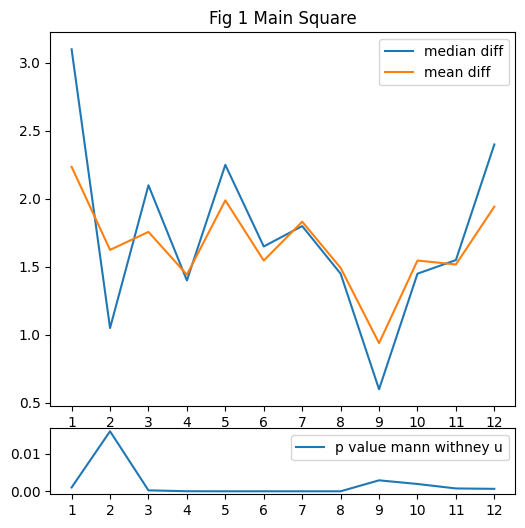

In [44]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(6, 6))

gs = gridspec.GridSpec(2, 1, height_ratios=[0.85, 0.15], hspace=0.1)

ax_main = fig.add_subplot(gs[0])
ax_footer = fig.add_subplot(gs[1])

for col in focus.columns:
  ax_main.plot(focus[col], label=col)

ax_footer.plot(results["p man withney u"], label="p value mann withney u")

ax_main.set_title("Fig 1 Main Square")
ax_main.legend()
ax_footer.legend()